<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/vacancies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latvia job vacancies — real labor market (case study)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 14 — AI transforms tasks, not jobs — redesign the workflow, keep humans accountable  
**Rows:** 3,491  ·  **Source file:** `latvia_job_vacancies.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/latvia_job_vacancies.csv"
LOCAL = "latvia_job_vacancies.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (3491, 5)


,position,company,work_address,salary_gross,valid_until
0,APKOPĒJS,"Sabiedrība ar ierobežotu atbildību ""FOREVERS""","Granīta iela 9A, Rīga",960 - 1200 EUR,31.10.2025
1,MAZUMTIRDZNIECĪBAS VEIKALA PĀRDEVĒJS,"Sabiedrība ar ierobežotu atbildību ""FOREVERS""","Jūrmalas iela 14, Piņķi, Babītes pag., Mārupes...",900 - 1100 EUR,31.10.2025
2,MAZUMTIRDZNIECĪBAS VEIKALA PĀRDEVĒJS,"Sabiedrība ar ierobežotu atbildību ""FOREVERS""","Atpūtas iela 1, Carnikava, Carnikavas pag., Ād...",900 - 1100 EUR,31.10.2025
3,IESAIŅOTĀJS (ROKU DARBS),"""MAXIMA Latvija"" SIA","Augusta Deglava iela 67, Rīga",5.25 - 5.45 EUR,31.10.2025
4,MAZUMTIRDZNIECĪBAS VEIKALA PĀRDEVĒJS,"""MAXIMA Latvija"" SIA","Slokas iela 115, Rīga",5.3 - 5.75 EUR,31.10.2025


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
position        str
company         str
work_address    str
salary_gross    str
valid_until     str

Missing values:
work_address    2


---
## Problem 1 · Easy — describe

What does the Latvian vacancy market look like?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Vacancies: {len(df):,}")
print("\nTop employers:\n", df["company"].value_counts().head(10))
print("\nTop locations (from work_address):")
print(df["work_address"].astype(str).str.extract(r"([A-ZĀČĒĢĪĶĻŅŠŪŽ][a-zāčēģīķļņšūž]+)")[0]
        .value_counts().head(10))

Vacancies: 3,491

Top employers:
 company
"MAXIMA Latvija" SIA                                                                          107
SIA "Rīgas Austrumu klīniskā universitātes slimnīca"                                           60
Valsts sabiedrība ar ierobežotu atbildību "Paula Stradiņa klīniskā universitātes slimnīca"     59
LENOKA SIA                                                                                     51
SIA "RIMI LATVIA"                                                                              42
Ieslodzījuma vietu pārvalde                                                                    41
SIA "Rīgas 1. slimnīca"                                                                        40
Rīgas Tehniskā universitāte                                                                    29
Valsts sociālās aprūpes centrs "Zemgale"                                                       29
Valsts policija                                                             

---
## Problem 2 · Intermediate — build

Parse the salary text into numbers — carefully.

*Try it yourself first. The worked solution is below.*

In [4]:
s = df["salary_gross"].astype(str)
nums = s.str.replace(r"[^\d\-–]", " ", regex=True).str.split()
def mid(v):
    vals = [float(x) for x in v if x.replace('.','').isdigit()]
    vals = [x for x in vals if 200 <= x <= 20000]     # plausible monthly gross
    return sum(vals)/len(vals) if vals else None
df["salary_mid"] = nums.apply(mid)
print(f"Rows with a usable salary: {df['salary_mid'].notna().sum():,} of {len(df):,}")
print(df["salary_mid"].describe().round(0))
print(f"\nMedian advertised gross: EUR {df['salary_mid'].median():,.0f}")

Rows with a usable salary: 2,797 of 3,491
count     2797.0
mean      1518.0
std        672.0
min        200.0
25%       1102.0
50%       1494.0
75%       1700.0
max      10953.0
Name: salary_mid, dtype: float64

Median advertised gross: EUR 1,494


---
## Problem 3 · Advanced — judge

Which roles pay most — and what is the honest caveat?

*Try it yourself first. The worked solution is below.*

In [5]:
top = (df.dropna(subset=["salary_mid"])
         .groupby("position")["salary_mid"].agg(n="size", median="median")
         .query("n >= 5").sort_values("median", ascending=False))
print("Best-paid roles (>=5 postings):\n", top.head(12).round(0))
print("\nLowest:\n", top.tail(6).round(0))
print("\nCaveat: these are ADVERTISED gross ranges, not paid salaries, and only")
print("a subset of ads state pay at all — that is a selection bias, so treat")
print("this as a picture of what employers ADVERTISE, not what people earn.")

Best-paid roles (>=5 postings):
                                                      n  median
position                                                      
ZOBĀRSTS                                             7  3500.0
SISTĒMANALĪTIĶIS                                     5  3325.0
PROGRAMMĒTĀJS                                        7  3092.0
NEIROLOGS                                            6  3004.0
FIZIKĀLĀS UN REHABILITĀCIJAS MEDICĪNAS ĀRSTS         7  3000.0
KARDIOLOGS                                           6  2779.0
BŪVDARBU VADĪTĀJS                                    8  2625.0
VADĪTĀJS /DIREKTORS /PĀRVALDNIEKS (IZGLĪTĪBAS J...   6  2592.0
PAMATDARBĪBAS STRUKTŪRVIENĪBAS VADĪTĀJS /DIREKT...   5  2516.0
PĒTNIEKS                                            10  2500.0
KLIENTU APKALPOŠANAS OPERATORS                       9  2125.0
VIRSMĀSA                                             6  2045.0

Lowest:
                              n  median
position                            

---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


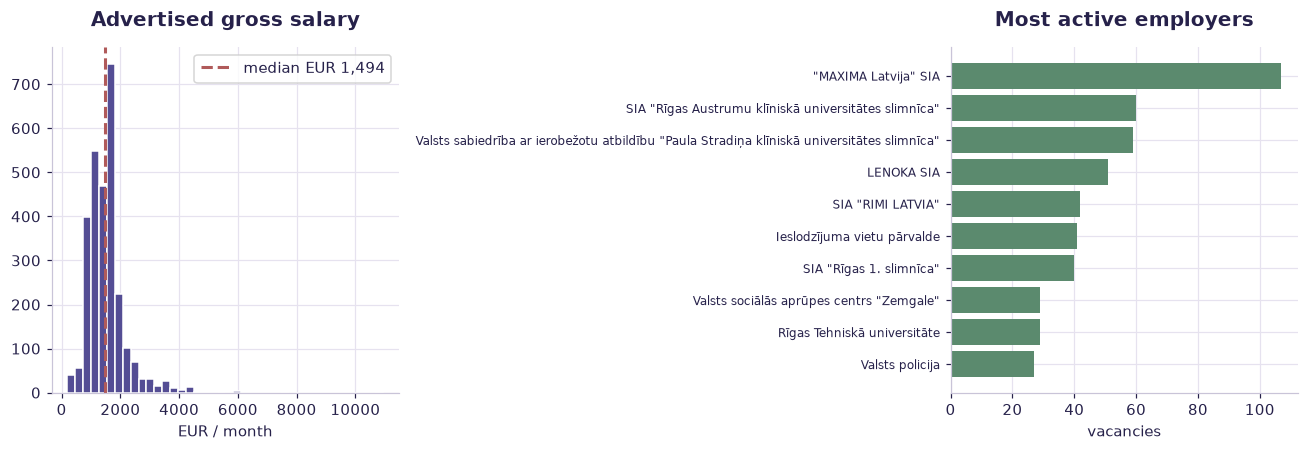

In [6]:
s = df["salary_gross"].astype(str).str.replace(r"[^\d\-–]", " ", regex=True).str.split()
def mid(v):
    vals = [float(x) for x in v if x.replace('.','').isdigit()]
    vals = [x for x in vals if 200 <= x <= 20000]
    return sum(vals)/len(vals) if vals else None
sal = s.apply(mid).dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].hist(sal, bins=40, color=ACCENT, edgecolor="white")
ax[0].axvline(sal.median(), color=DANGER, ls="--", lw=2, label=f"median EUR {sal.median():,.0f}")
ax[0].set_title("Advertised gross salary"); ax[0].set_xlabel("EUR / month"); ax[0].legend()

top = df["company"].value_counts().head(10).sort_values()
ax[1].barh(top.index, top.values, color=CORE)
ax[1].set_title("Most active employers"); ax[1].set_xlabel("vacancies")
ax[1].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. 3,491 real vacancies; ~2,800 list a parseable salary → median €1,494 gross (below the ~€1,500 national average)
2. Rīga dominates: 1,541 of 3,491 (44%) — the capital-concentration story in one column
3. Top roles are manual/service: labourer (213), HGV driver (137), retail seller (113), cleaner (82)
4. The AI trap: ~20% of rows have no numeric salary — a naive parser silently drops them and biases the median upward
5. Great GenAI use case: title → occupation family (ISCO) is a classification task AI does well but must be spot-checked


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Workflow redesign canvas (before/after + classifications + controls) and the human ownership map.

---
*Applied AI Academy · appliedai.center*
